In [2]:
import os
import pandas as pd
from scipy.stats import chi2_contingency
import numpy as np

DATA_DIR = "../data"

# Load per-language bias metrics
perlang_df = pd.read_csv(os.path.join(DATA_DIR, "bias_metrics_perlang.csv"))

# Load occupation mapping
occ_df = pd.read_csv(os.path.join(DATA_DIR, "bias_metrics_occupation.csv"))
if "qid" not in occ_df.columns and "item" in occ_df.columns:
    occ_df = occ_df.rename(columns={"item": "qid"})

# Merge occupation with per-language
df_occ = perlang_df.merge(
    occ_df[["qid", "occupation_category"]],
    on="qid", how="inner"
).dropna(subset=["occupation_category"])

print(f"Merged occupation rows: {df_occ.shape}")

# Build contingency table: rows = occupation categories, cols = languages
contingency = pd.crosstab(df_occ["occupation_category"], df_occ["language"])
print("\nContingency table (top 5 rows):")
print(contingency.head())

# Chi-squared test
chi2, p, dof, expected = chi2_contingency(contingency)

# Effect size: Cramér's V
n = contingency.values.sum()
cramers_v = np.sqrt(chi2 / (n * (min(contingency.shape)-1)))

print("\n=== Chi-squared test (Occupation) ===")
print(f"Chi2 = {chi2:.2f}, df = {dof}, p = {p:.4e}")
print(f"Cramér's V (effect size) = {cramers_v:.3f}")


Merged occupation rows: (659, 9)

Contingency table (top 5 rows):
language                       de  en  hi  ja
occupation_category                          
Arts, Literature & Humanities  70  93  24  44
Economics & Politics           65  79  25  34
Science                        12  20   6   7
Sports                         49  86  14  31

=== Chi-squared test (Occupation) ===
Chi2 = 5.75, df = 9, p = 7.6445e-01
Cramér's V (effect size) = 0.054



=== Chi-squared test (Occupation × Language) ===
Chi2 = 5.75, df = 9, p = 7.6445e-01
Cramér's V = 0.054


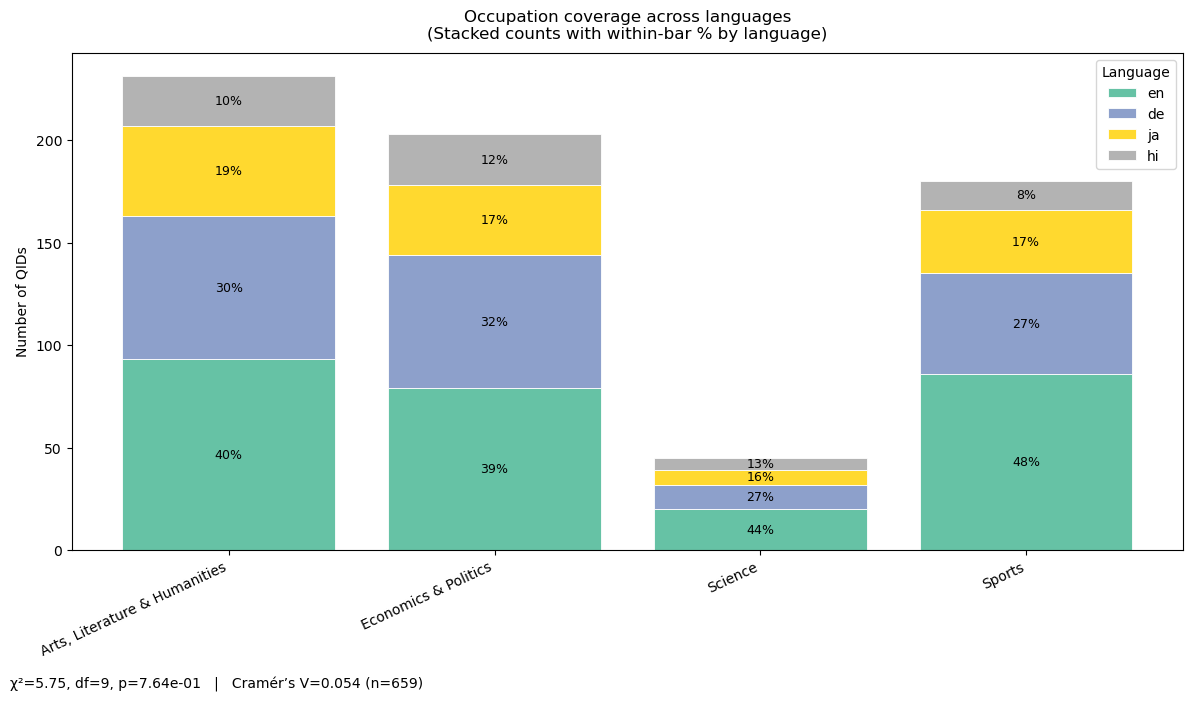

Saved: ../plots/stat_viz/occupation_language_chi2_stacked_counts_with_pct.png


In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

PLOTS_DIR = "../plots/stat_viz"
os.makedirs(PLOTS_DIR, exist_ok=True)

# --- Build contingency table: rows=occupation_category, cols=language ---
cont = pd.crosstab(df_occ["occupation_category"], df_occ["language"]).sort_index()

# Optional: order languages by total volume (so legend & stacks are consistent)
lang_order = cont.sum(axis=0).sort_values(ascending=False).index.tolist()
cont = cont[lang_order]

# Chi-squared + effect size
chi2, p, dof, expected = chi2_contingency(cont)
n = cont.values.sum()
cramers_v = np.sqrt(chi2 / (n * (min(cont.shape) - 1)))

print("\n=== Chi-squared test (Occupation × Language) ===")
print(f"Chi2 = {chi2:.2f}, df = {dof}, p = {p:.4e}")
print(f"Cramér's V = {cramers_v:.3f}")

# --- Percent labels per occupation (row-wise percent by language) ---
row_totals = cont.sum(axis=1).replace(0, np.nan)
row_perc = (cont.div(row_totals, axis=0) * 100).round(1)  # % within each occupation

# --- Plot: stacked bars with counts on Y and % labels inside segments ---
plt.figure(figsize=(12, 7))
colors = plt.cm.Set2(np.linspace(0, 1, cont.shape[1]))  # one color per language

bottom = np.zeros(len(cont), dtype=float)
x = np.arange(len(cont.index))

bars = []
for i, lang in enumerate(cont.columns):
    y = cont[lang].values
    bar = plt.bar(x, y, bottom=bottom, label=lang, color=colors[i], edgecolor="white", linewidth=0.6)
    bars.append(bar)

    # add % labels inside each segment (only if the segment is nonzero)
    for xi, (count, btm) in enumerate(zip(y, bottom)):
        if count > 0:
            pct = row_perc.iloc[xi, i]
            # Midpoint of this segment for label positioning
            y_mid = btm + count / 2.0
            # Show percentage label
            plt.text(xi, y_mid, f"{pct:.0f}%", ha="center", va="center", fontsize=9, color="black")
    bottom += y

# Axes & labels
plt.xticks(x, cont.index, rotation=25, ha="right")
plt.ylabel("Number of QIDs")
plt.title("Occupation coverage across languages\n(Stacked counts with within-bar % by language)", pad=10)
plt.legend(title="Language", frameon=True)

# Annotate χ², p, df, Cramér’s V
txt = f"χ²={chi2:.2f}, df={dof}, p={p:.2e}   |   Cramér’s V={cramers_v:.3f} (n={n})"
plt.gcf().text(0.01, 0.01, txt, fontsize=10)

plt.tight_layout(rect=[0, 0.03, 1, 1])
out_png = os.path.join(PLOTS_DIR, "occupation_language_chi2_stacked_counts_with_pct.png")
plt.savefig(out_png, dpi=200)
plt.show()

print(f"Saved: {out_png}")


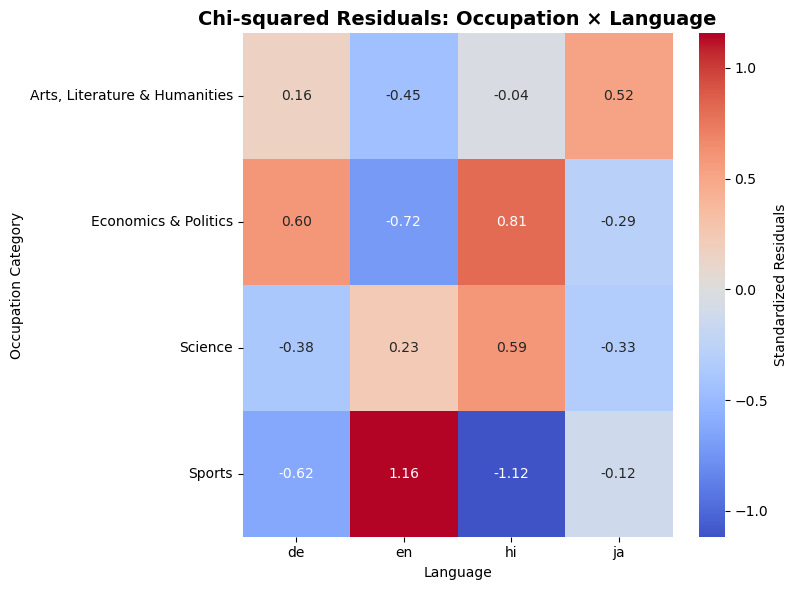

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

# Contingency table (replace with your full data if needed)
data = {
    "de": [70, 65, 12, 49],
    "en": [93, 79, 20, 86],
    "hi": [24, 25, 6, 14],
    "ja": [44, 34, 7, 31]
}
index = ["Arts, Literature & Humanities", "Economics & Politics", "Science", "Sports"]
contingency = pd.DataFrame(data, index=index)

# Chi-squared
chi2, p, dof, expected = chi2_contingency(contingency)

# Standardized residuals
residuals = (contingency - expected) / np.sqrt(expected)
resid_df = pd.DataFrame(residuals, index=index, columns=contingency.columns)

# --- Plot heatmap of residuals ---
plt.figure(figsize=(8,6))
sns.heatmap(resid_df, annot=True, cmap="coolwarm", center=0, fmt=".2f",
            cbar_kws={"label": "Standardized Residuals"})
plt.title("Chi-squared Residuals: Occupation × Language", fontsize=14, weight="bold")
plt.ylabel("Occupation Category")
plt.xlabel("Language")
plt.tight_layout()
plt.show()


=== Contingency Table (first 10 rows) ===
language                       de                        en                   \
pagerank_bin                  Low Mid-Low Mid-High High Low Mid-Low Mid-High   
occupation_category                                                            
Arts, Literature & Humanities  15      28       18    9  33      20       16   
Economics & Politics           12      20       18   15  25      16       24   
Science                         1       5        3    3  10       4        0   
Sports                          4      20       16    9  17      26       17   

language                            hi                        ja          \
pagerank_bin                  High Low Mid-Low Mid-High High Low Mid-Low   
occupation_category                                                        
Arts, Literature & Humanities   24   6       3        4   11  11       4   
Economics & Politics            14  13       4        2    6  11       7   
Science          

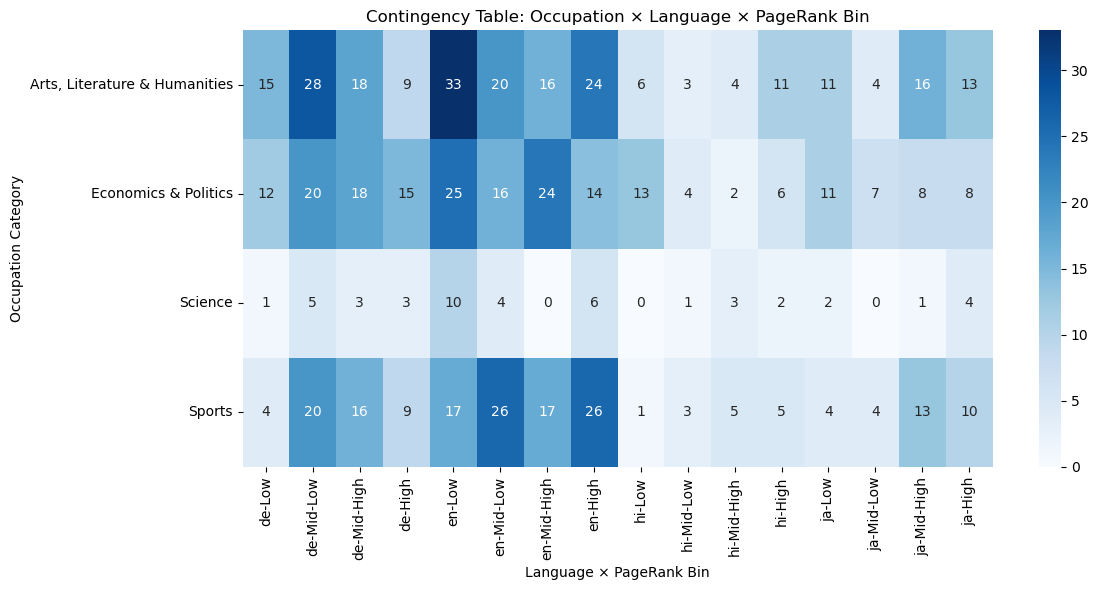

In [5]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt
import seaborn as sns

# --- Load occupation-merged dataframe ---
# df_occ should already contain: ['qid','language','occupation_category','pagerank_norm_perlang']

# Step 1: Bin PageRank values (e.g., into quartiles)
df_occ["pagerank_bin"] = pd.qcut(df_occ["pagerank_norm_perlang"], q=4, labels=["Low","Mid-Low","Mid-High","High"])

# Step 2: Build contingency table
contingency = pd.crosstab(index=[df_occ["occupation_category"]],
                          columns=[df_occ["language"], df_occ["pagerank_bin"]])

print("=== Contingency Table (first 10 rows) ===")
print(contingency.head(10))

# Step 3: Run Chi-squared test
chi2, p, dof, expected = chi2_contingency(contingency)

# Cramér's V for effect size
n = contingency.sum().sum()
cramers_v = np.sqrt(chi2 / (n * (min(contingency.shape)-1)))

print("\n=== Chi-squared Test for PageRank (Occupation × Language) ===")
print(f"Chi2 = {chi2:.2f}, df = {dof}, p = {p:.4e}")
print(f"Cramér's V = {cramers_v:.3f}")

# Step 4: Optional heatmap visualization of expected vs observed
plt.figure(figsize=(12,6))
sns.heatmap(contingency, annot=True, fmt="d", cmap="Blues")
plt.title("Contingency Table: Occupation × Language × PageRank Bin")
plt.ylabel("Occupation Category")
plt.xlabel("Language × PageRank Bin")
plt.tight_layout()
plt.show()



Contingency table (top 10 rows):
language            de   en   hi   ja
instance_category                    
Creative Work       50  121   36   64
Organisation        25   40    6   30
Person             263  402  105  207
Place               85  114  137   57

=== Chi-squared test (Instance) ===
Chi2 = 143.44, df = 9, p = 2.0067e-26
Cramér's V (effect size) = 0.166


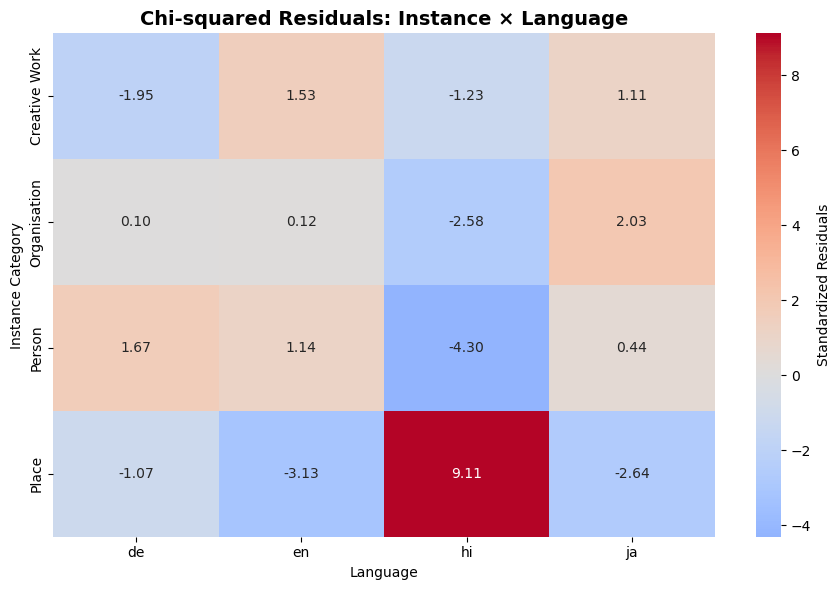


 Residual heatmap saved to: ../plots/chi2_instance_residuals.png


In [6]:
import os
import pandas as pd
from scipy.stats import chi2_contingency
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

DATA_DIR = "../data"
PLOTS_DIR = "../plots"
os.makedirs(PLOTS_DIR, exist_ok=True)

# Load per-language bias metrics
perlang_df = pd.read_csv(os.path.join(DATA_DIR, "bias_metrics_perlang.csv"))

# Load instance mapping
inst_map = pd.read_csv(os.path.join(DATA_DIR, "bias_metrics_instance.csv"))
if 'qid' not in inst_map.columns and 'item' in inst_map.columns:
    inst_map = inst_map.rename(columns={'item': 'qid'})

# Choose correct column
prop_col = "instance_category" if "instance_category" in inst_map.columns else "instanceOfLabel"

# Merge
df_inst = perlang_df.merge(inst_map[['qid', prop_col]], on="qid", how="inner").dropna(subset=[prop_col])

# Contingency table
contingency = df_inst.groupby([prop_col, "language"])["qid"].nunique().unstack(fill_value=0)

print("\nContingency table (top 10 rows):")
print(contingency.head(10))

# Chi-squared test
chi2, p, dof, expected = chi2_contingency(contingency)
print("\n=== Chi-squared test (Instance) ===")
print(f"Chi2 = {chi2:.2f}, df = {dof}, p = {p:.4e}")

# Effect size (Cramér’s V)
n = contingency.to_numpy().sum()
k = min(contingency.shape) - 1
cramers_v = np.sqrt(chi2 / (n * k))
print(f"Cramér's V (effect size) = {cramers_v:.3f}")

# Standardized residuals
residuals = (contingency - expected) / np.sqrt(expected)
resid_df = pd.DataFrame(residuals, index=contingency.index, columns=contingency.columns)

# Heatmap (save + show)
plt.figure(figsize=(9,6))
sns.heatmap(resid_df, annot=True, cmap="coolwarm", center=0, fmt=".2f",
            cbar_kws={"label": "Standardized Residuals"})
plt.title("Chi-squared Residuals: Instance × Language", fontsize=14, weight="bold")
plt.ylabel("Instance Category")
plt.xlabel("Language")
plt.tight_layout()
out_path = os.path.join(PLOTS_DIR, "chi2_instance_residuals.png")
plt.savefig(out_path, dpi=150)
plt.show()

print(f"\n Residual heatmap saved to: {out_path}")


In [7]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

# --- Prep: ensure needed columns are present ---
need = {"language", "occupation_category", "clustering_norm_perlang"}
assert need.issubset(df_occ.columns), f"df_occ missing columns: {need - set(df_occ.columns)}"

df = df_occ.dropna(subset=["clustering_norm_perlang", "language", "occupation_category"]).copy()
x = df["clustering_norm_perlang"].astype(float)

# --- Robust binning for clustering (handles many zeros / ties) ---
labels_full = ["Low", "Mid-Low", "Mid-High", "High"]
try:
    # Try standard quartiles, but allow duplicate edges to be dropped
    bins = pd.qcut(x, q=4, labels=labels_full, duplicates="drop")
    n_levels = bins.cat.categories.size
    # If we ended up with <2 bins, fall back
    if n_levels < 2:
        raise ValueError("Too few unique bins after qcut.")
    df["clustering_bin"] = bins
except Exception:
    # Fallback: separate zeros, then quantile-bin the positive mass
    zero_mask = x == 0
    df["clustering_bin"] = pd.Series(index=df.index, dtype="object")
    df.loc[zero_mask, "clustering_bin"] = "Zero"

    pos = x[~zero_mask]
    if pos.empty or pos.nunique() == 1:
        # Everything is zero or one unique positive value -> binary binning
        df.loc[~zero_mask, "clustering_bin"] = "Non-zero"
    else:
        # Bin non-zero values into tertiles (or fewer if ties persist)
        pos_bins = pd.qcut(pos, q=3, labels=["Low+", "Mid+", "High+"], duplicates="drop")
        df.loc[pos_bins.index, "clustering_bin"] = pos_bins.astype(str)

    df["clustering_bin"] = df["clustering_bin"].astype("category")

# --- Build contingency table: occupation × (language × clustering_bin) ---
cont = pd.crosstab(
    df["occupation_category"],
    [df["language"], df["clustering_bin"]]
)

# Drop any all-zero columns (rare but safe)
cont = cont.loc[:, cont.sum(axis=0) > 0]

print("=== Contingency Table (first 10 rows) ===")
print(cont.head(10))

# --- Chi-squared test ---
chi2, p, dof, expected = chi2_contingency(cont)

# --- Effect size (Cramér's V) ---
n = cont.to_numpy().sum()
r, c = cont.shape
cramers_v = np.sqrt(chi2 / (n * (min(r, c) - 1)))

print("\n=== Chi-squared Test for Clustering (Occupation × Language) ===")
print(f"Chi2 = {chi2:.2f}, df = {dof}, p = {p:.4f}")
print(f"Cramér's V = {cramers_v:.3f}")


=== Contingency Table (first 10 rows) ===
language                        de              en                   hi       \
clustering_bin                Low+ Mid+ Zero High+ Low+ Mid+ Zero High+ Mid+   
occupation_category                                                            
Arts, Literature & Humanities    1    0   69     0    3    0   90     1    1   
Economics & Politics             1    0   64     1    3    1   74     0    0   
Science                          1    0   11     1    0    0   19     0    1   
Sports                           0    2   47     3    0    4   79     0    0   

language                              ja                 
clustering_bin                Zero High+ Low+ Mid+ Zero  
occupation_category                                      
Arts, Literature & Humanities   22     2    0    1   41  
Economics & Politics            25     1    2    1   30  
Science                          5     1    0    0    6  
Sports                          14     2    1    